# HomologyRing Package: Example usage
The core functionality of the pipeline, is the creation of a homology enriched Residue Interaction Network (hRIN) for a protein family. Secondary functionality includes many feature for analyzing said networks.

## Software Requirements: 
All of the following must be installed and added to PATH.
- RING (v4 or higher for use of all features): 
- NCBI BLAST Commandline: 
- ClustalOmega Commandline: 

## File Requirements:  
BLAST commandline requires compiled database files on the local system and the files location must be passed when invoking HomologyRing. Copies of of the Swissprot and PDB databases are distributed in this repo, but may be out of date. Their relative locations in this repo are 'blast_db/pdb_seqres' and 'blast_db/uniprot_sprot.fasta' for PDB and Swissprot respectively. Instructions for compiling Blast Databases can be found here: 
https://www.ncbi.nlm.nih.gov/books/NBK569841/  
BLAST database schemas can very, and may require modification of pipeline/config.json for successful parsing. 
Note that BLAST searches can be optionally executed remotely on NCBI servers using HomologyRing, forgoing the need for local databases, but is slow and not recommended.

## Python Requirements:  
Developed and tested on Python 3.11.0  
Dependencies should be automatically handled with running "pip install .", but are listed below.  
- pandas
- numpy
- matplotlib
- plotly
- requests
- networkx
- biopython
- pdbecif
- scipy

# Package installation
HomologyRing may be used in a verity of ways, including as a python package, or a standalone script, which may be invoked from the commandline.  
Installing the package and linked python package requirements may be done by executing the following cell.


In [ ]:
!pip install .

# Example Usage
Because creation of an hRIN involves a somewhat long pipeline, a lot of parameters need to be passed to allow flexibility. As a result, the process requires invoking two methods in python: one to instantiate the HomologyRing object, and another to initiate the pipeline, or the 'build'.  
There are various ways an hRIN may be built, either by performing a BLAST homology search to find family members, or by providing a user-defined protein family.

In [7]:
from pipeline import HomologyRing
import logging # used for adjusting Log levels
blast_DBs = {'PDB':'blast_db/pdb_seqres', 'SPROT':'blast_db/uniprot_sprot.fasta'} # Paths of local BLAST databases

## Building with local BLAST search

In [10]:
# For family from PDB structures
HR_BLAST_PDB = HomologyRing.HomologyRing('query/1LM8.cif', blast_DBs['PDB'], struct_source='PDB', uses_PDB_ids=True)
HR_BLAST_PDB.build('C','1', force_download=False, force_RING=False, max_results=128, use_label_asym_id=False, prob_normalization='possible')

Bad edges found: 9 instances in ['7pi4', '6zhc', '8bdt']. They have been filtered, but this issue should be resolved.
Wrote files ['network_out/1LM8_nodes.tsv', 'network_out/1LM8_edges.tsv']


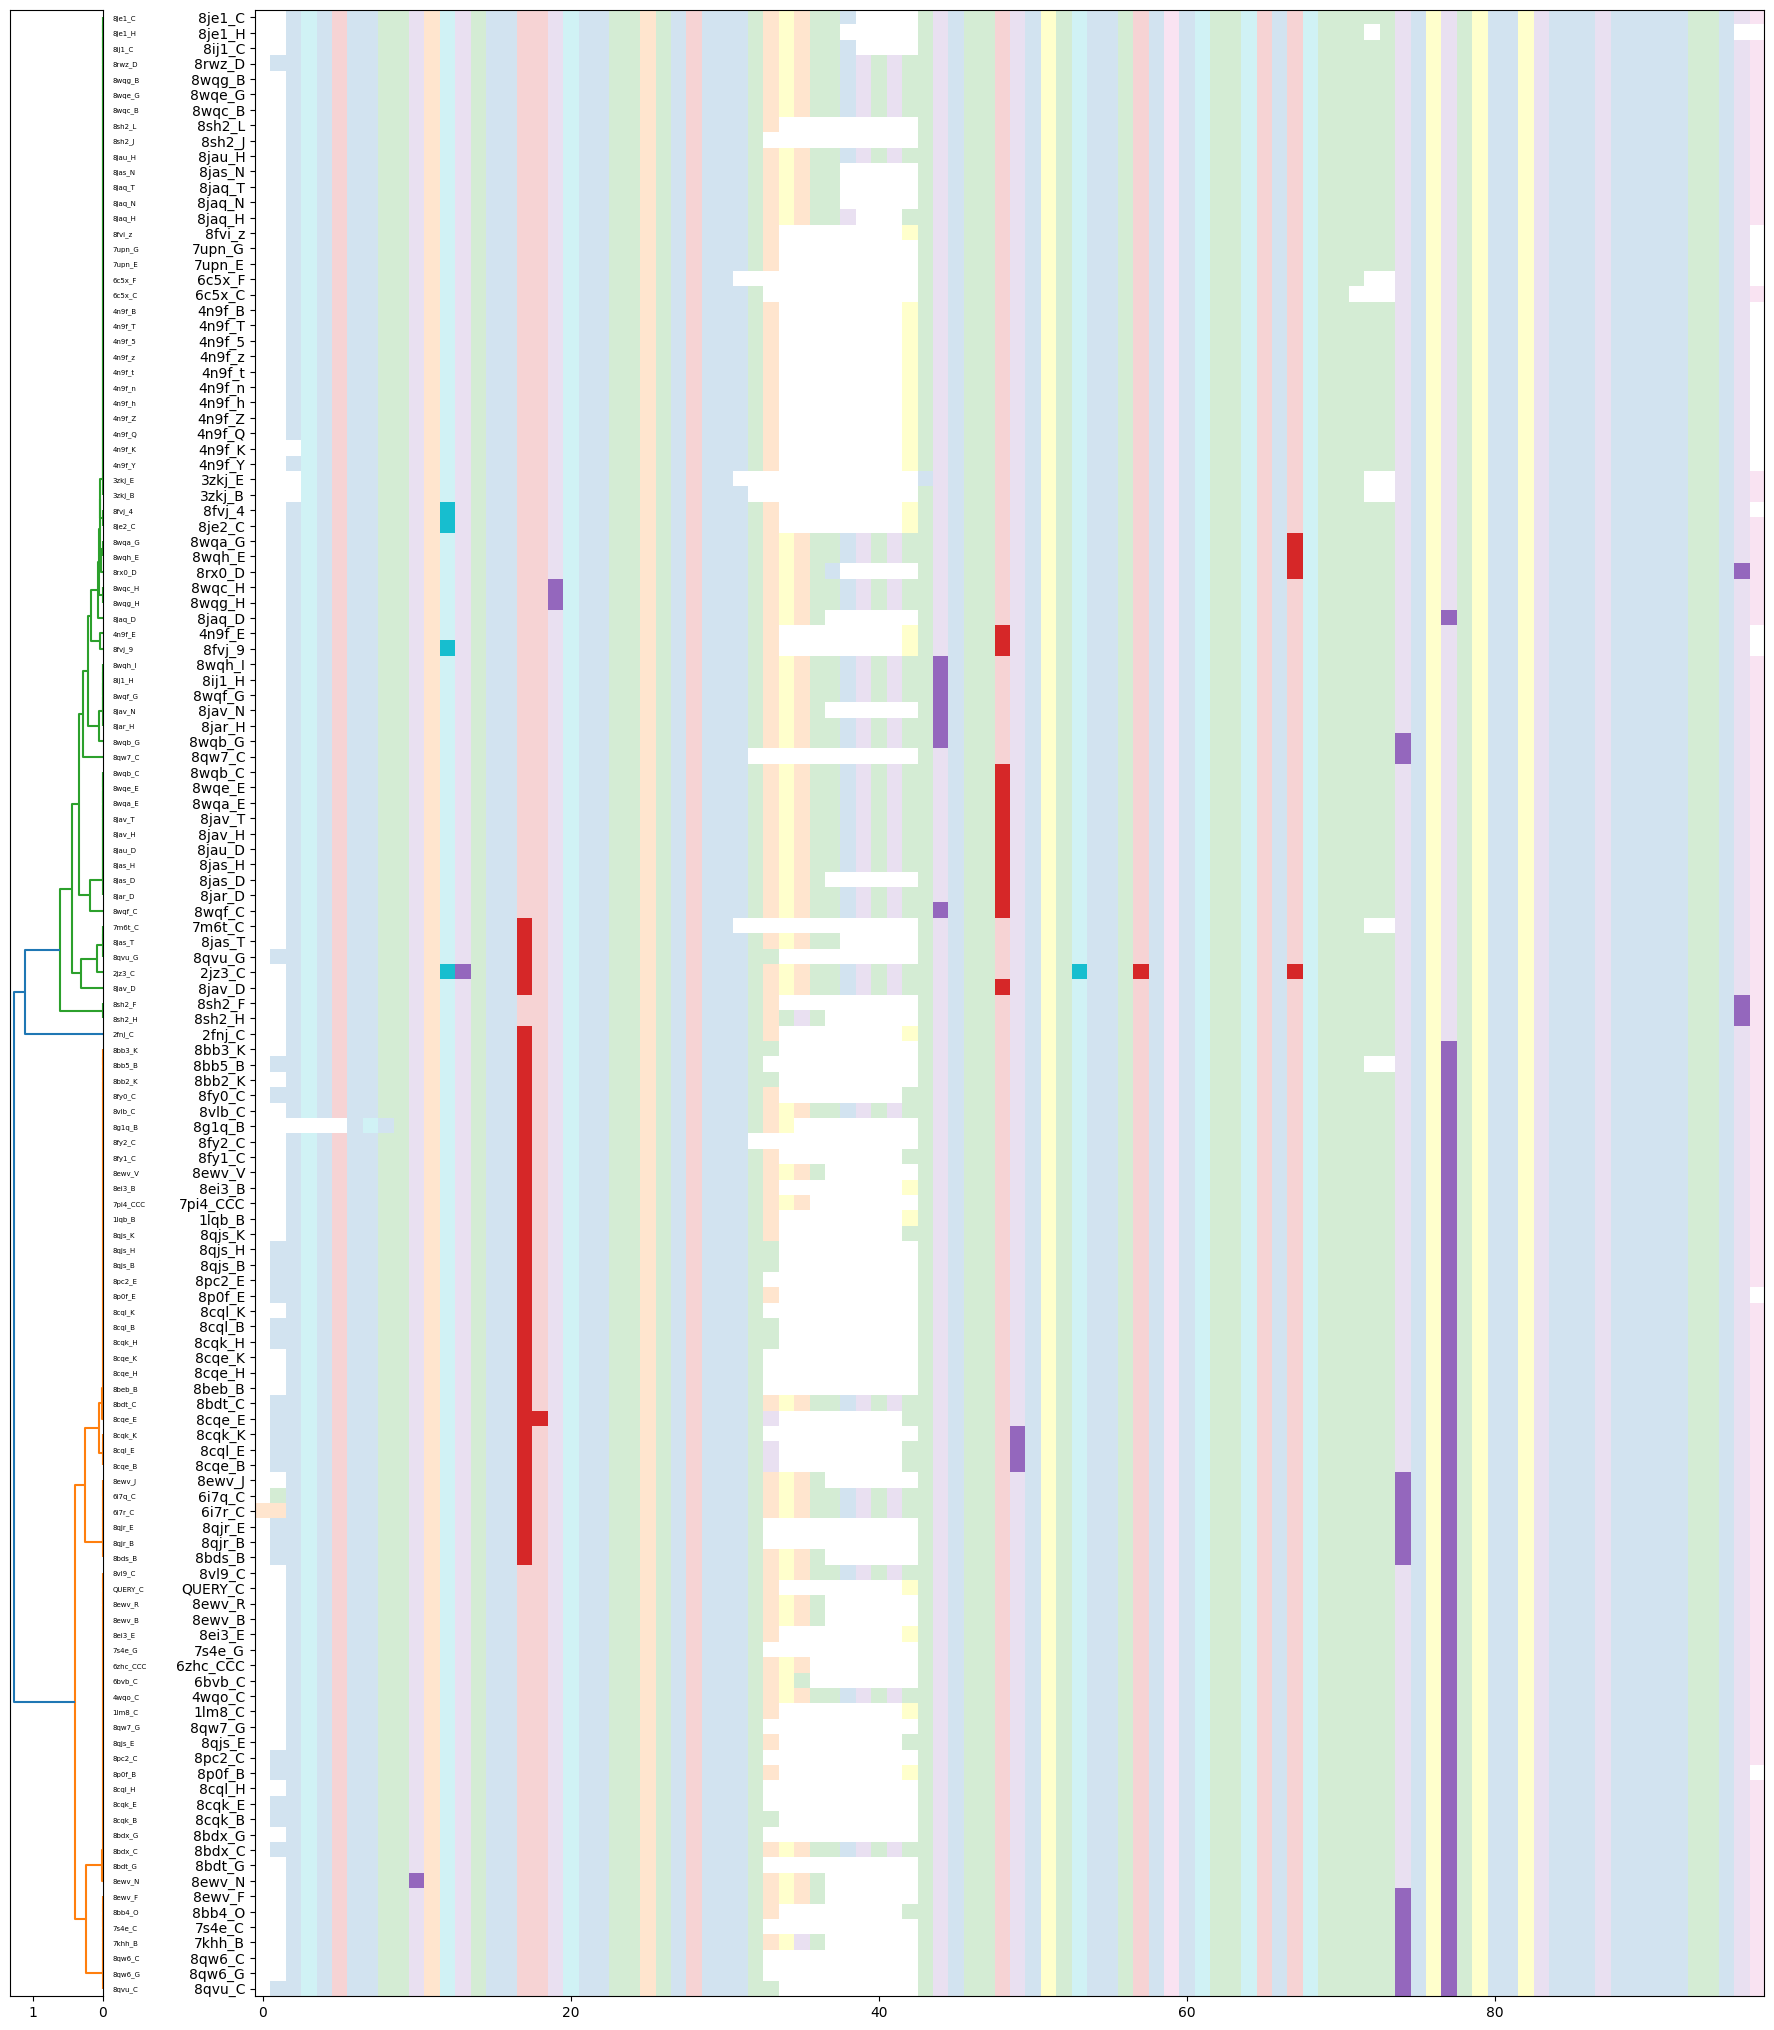

([7,
  6,
  9,
  11,
  17,
  20,
  23,
  30,
  31,
  38,
  41,
  46,
  47,
  48,
  55,
  64,
  65,
  72,
  73,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  87,
  88,
  89,
  54,
  5,
  26,
  15,
  10,
  22,
  16,
  49,
  86,
  53,
  14,
  8,
  19,
  35,
  44,
  25,
  96,
  24,
  21,
  27,
  34,
  36,
  39,
  42,
  43,
  45,
  18,
  69,
  40,
  100,
  90,
  37,
  33,
  32,
  91,
  3,
  1,
  4,
  12,
  28,
  50,
  51,
  52,
  56,
  63,
  68,
  92,
  101,
  102,
  104,
  107,
  109,
  111,
  114,
  116,
  119,
  120,
  123,
  127,
  121,
  115,
  113,
  122,
  59,
  13,
  94,
  105,
  106,
  128,
  29,
  0,
  57,
  61,
  62,
  66,
  71,
  74,
  75,
  93,
  95,
  103,
  108,
  110,
  112,
  117,
  118,
  124,
  125,
  126,
  58,
  60,
  2,
  67,
  70,
  97,
  98,
  99],
 ['8je1_C',
  '8je1_H',
  '8ij1_C',
  '8rwz_D',
  '8wqg_B',
  '8wqe_G',
  '8wqc_B',
  '8sh2_L',
  '8sh2_J',
  '8jau_H',
  '8jas_N',
  '8jaq_T',
  '8jaq_N',
  '8jaq_H',
  '8fvi_z',
  '7upn_G',
  '7upn_E',
  

In [14]:
HR_BLAST_PDB.plot_contact_conservation('IONIC', 'inter')

In [11]:
# For family from AlphaFold structures
HR_BLAST_AF = HomologyRing.HomologyRing('query/1LM8.cif', blast_DBs['SPROT'], struct_source='AlphaFold', uses_PDB_ids=False)
HR_BLAST_AF.build('C','1', force_download=True, force_RING=False, max_results=16, use_label_asym_id=False, prob_normalization='possible')

Wrote files ['network_out/1LM8_nodes.tsv', 'network_out/1LM8_edges.tsv']


## Building with local BLAST search
The following cells may be executed as an alternative to the above. They utilize remote execution of BLAST on NCBI servers.  
In this case, the blast_db argument is no longer taken to be a path to a local database file, but rater the name of a database on NCBI servers. Valid options are 'pdb' and 'swissprot'.

In [3]:
# For family from PDB structures, remote exec
HR_BLAST_PDB = HomologyRing.HomologyRing('query/1LM8.cif', 'pdb', struct_source='PDB', uses_PDB_ids=True)
HR_BLAST_PDB.build('C','1', force_download=False, force_RING=False, max_results=16, use_label_asym_id=False, prob_normalization='possible', remote_BLAST=True)

Wrote files ['network_out/1LM8_nodes.tsv', 'network_out/1LM8_edges.tsv']


In [4]:
# For family from AlphaFold structures, remote exec
HR_BLAST_AF = HomologyRing.HomologyRing('query/1LM8.cif', 'swissprot', struct_source='AlphaFold', uses_PDB_ids=False)
HR_BLAST_AF.build('C','1', force_download=False, force_RING=False, max_results=16, use_label_asym_id=False, prob_normalization='possible', remote_BLAST=True)

Exception: Unknown / unsupported BLAST output scheme.

### HomologyRing instantiation
Use of the HomologyRing module requires instantiation to prepare the object for the creation of an hRIN according to the users requirements by passing the following arguments:
- query_file (str, required): path to query CIF structure file that will serve as a reference for the construction hRIN. For building with a BLAST search, the query sequence for the search will be extracted from this file.
- blast_DB (str, required): path to your local installation of your BLAST database.
- struct_source (str, optional, default='AlphaFold'): Database from which structures corresponding to BLAST matches will be download. Supported values are 'AlphaFold', 'PDB', and 'AlphaFill'.
- uses_PDB_ids (bool, optional, default=False): Indicates if members in family are to be identified by PDB ascensions. The choice will correspond with the users choice of database and effects parsing and the internal identification of member structures.
- interchain_edges (str, optional, default='single'): Residues in non-homolog (non-member) chains are identified as single corresponding to which entity they belong to. This simplifies Alignment process, but can lead to many contacts between a pair of nodes. 'single' will keep only one contact per interaction type in this case.
### Build
- chain_id (str): asym(chain)_id of query chain e.g. 'C', 'AA'. Affected by use_label_asym_id.
- state_id (str): State to use when multiple present in a file.
- max_results (int, optional, default=32): The max number of homologs to be included in the family from the BLAST results.
- eval (float, optional, default=0.001): E-value threshold used by the BLAST search.
- remote_BLAST (bool, optional, default=False): Enables the use of blast execution on NCBI servers. Takes a long time.
- force_download (bool, optional): Will re-download structure files, even if they already exist in the CIF dir.
- force_RING (bool, optional): Will force the execution of RING, even if output files already exist in the ring_out dir.
- use_label_asym_id (bool, optional): Requires ring4 or higher be installed locally. Allows use of label_asym_id chain identifiers to be used internally and when specifying query chain.
- prob_normalization (str, optional, default='strong'): Method to use when calculation the probability edge weights. See docs for details. Options are 'strong' and 'possible'.

## Saving Families
Once a family is created, its member structures may be saved, allowing for easy reconstruction later.

In [ ]:
HR_BLAST_PDB.save_family('family_ex.tsv')

## Building from user-defined family
A hRIN may be created from a set of structures provided by the user, avoiding the need to perform a BLAST search. In this case, a tsv file must be given with at least three columns: 'path', 'chain' and either 'UNP' or 'PDB'. 
Path contains **absolute paths** to structure files and the chain column indicates which chain in the structure is to be considered homolog chains to be included in the family. Depending on the value of the use_label_asym_id parameter when calling the HomologyRing.build_fromFamily method, these values will be taken as either auth or label chain identifiers accordingly. In the event that a multimer structure contains more than one homolog chain to be included in the family, each chain should get it's own row. 
Additionally this method is used to load previously saved families.

In [7]:
family_dir = 'family_ex.tsv'
### Note that a query structure is needed even though no BLAST search is performed.
### This is needed because some visulizations need a reference for position information.
### Choosing a representative member of your family will work well.
HR_USER = HomologyRing.HomologyRing('query/1LM8.cif', blast_DBs['PDB'], struct_source='PDB', log_level=logging.DEBUG, uses_PDB_ids=True)
tst = HR_USER.build_fromFamily(family_dir, 'C','1', force_RING=False, use_label_asym_id=False)

## Commandline Usage
The core functionality of the HomologyRing pipeline can be used through the CLI for easy integration into other workflows. This is useful if you your primary need is the network output files. For other analysis, the methods will need to be accessed through python script.  
This supports family construction from a BLAST search and from a user-defined tsv. Example usage is below: 

In [ ]:
!python3 pipeline/HomologyRing.py -q query/1LM8.cif -c C -db blast_db/pdb_seqres --use_pdb_ids 

Detailed infromation about arguments can be seen by invoking -h:

In [ ]:
!python3 pipeline/HomologyRing.py -h

## Interactive Dash Web Application (Work in Progress)
Building your family from the main() section of the plotly_app.py file will launch an interactive web app where properties of your protein family may be explored with dynamic plots and readouts. Many functions still need to be implemented.

# Pipeline File Output
Several files are created as a result of pipeline execution. 
Most important are the network files found in 'network_out' directory. These are tsv files created in pairs: one corresponding to the hRIN nodes and the other edges. These can be directly imported to Cytoscape, among other applications, for further analysis.  
Of additional note are other files created as artifacts of the pipeline such as msa.fasta in the root directory, which is the alined fasta file created by ClustalOmega and is the reference used to define nodes in the hRIN.

# Python Analysis Methods
## Helper Methods
Many methods were devloped as part of this package to aid in the analysis of hRINs. Here I will showcase some of the most commonly used methods. However, for a more complete and detailed explanation of their use, one should refer to the docs.

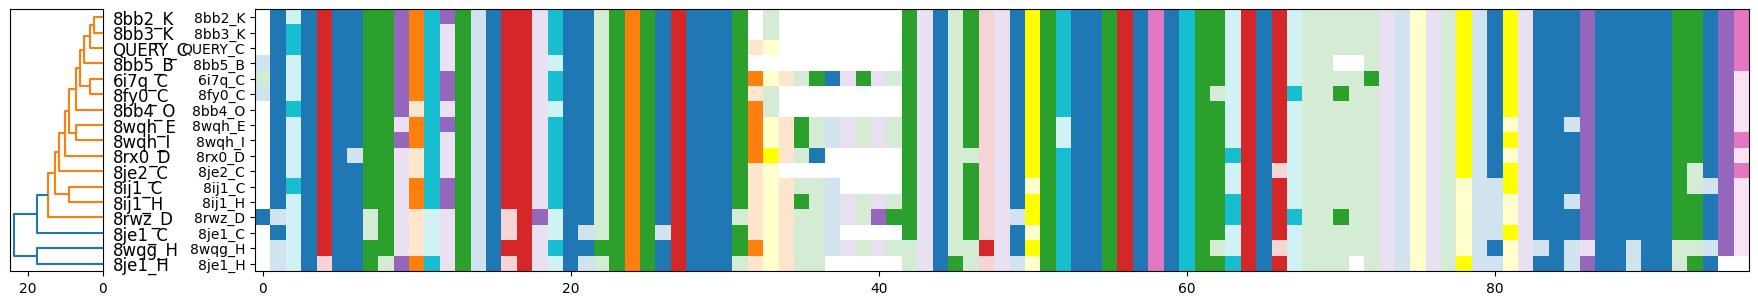

([4, 3, 0, 1, 13, 12, 2, 15, 14, 10, 5, 9, 8, 11, 7, 16, 6],
 ['8bb2_K',
  '8bb3_K',
  'QUERY_C',
  '8bb5_B',
  '6i7q_C',
  '8fy0_C',
  '8bb4_O',
  '8wqh_E',
  '8wqh_I',
  '8rx0_D',
  '8je2_C',
  '8ij1_C',
  '8ij1_H',
  '8rwz_D',
  '8je1_C',
  '8wqg_H',
  '8je1_H'])

In [6]:
## Contact conservation plots
## Allow for comparison of structures based on contact similarity. And observation of key/highly conserved interactions
## Supports filtering arguments to look at a subset of interactions
HR_BLAST_PDB.plot_contact_conservation('HBOND', 'intra')

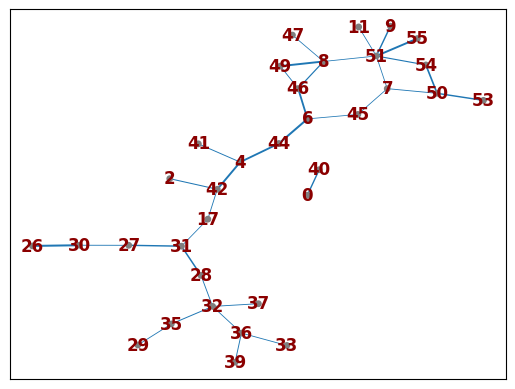

In [5]:
HR_BLAST_PDB.plot_hRIN_network(inter_types='HBOND', inter_class='intra', trim=(30,50))

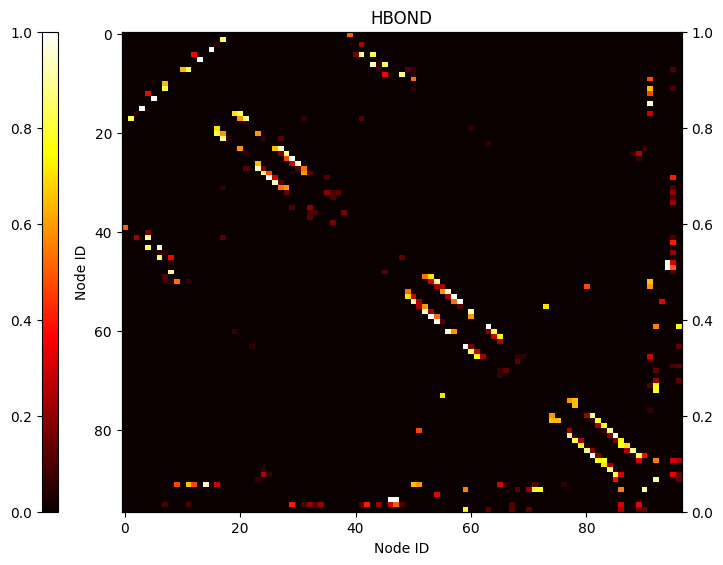

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 {0: 0,
  1: 1,
  2: 2,
  3: 3,
  4: 4,
  5: 5,
  6: 6,
  7: 7,
  8: 8,
  9: 9,
  10: 10,
  11: 11,
  12: 12,
  13: 13,
  14: 14,
  15: 15,
  16: 16,
  17: 17,
  18: 18,
  19: 19,
  20: 20,
  21: 21,
  22: 22,
  23: 23,
  24: 24,
  25: 25,
  26: 26,
  27: 27,
  28: 28,
  29: 29,
  30: 30,
  31: 31,
  32: 32,
  33: 33,
  34: 34,
  35: 35,
  36: 36,
  37: 37,
  38: 39,
  39: 40,
  40: 41,
  41: 42,
  42: 43,
  43: 44,
  44: 45,
  45: 46,
  46: 47,
  47: 48,
  48: 49,
  49: 50,
  50: 51,
  51: 52,
  52: 53,
  53: 54,
  54: 55,
  55: 56,
  56: 57,
  57: 58,
  58: 59,
  59: 60,
  60: 61,
  61: 62,
  62: 63,
  63: 64,
  64: 65,
  65: 66,
  66: 67,
  67: 69,
  68: 70,
  69: 72,
  70: 73,
  71: 76,
  72: 77,
  73: 78,
  74: 80,
  75: 81,
  76: 82,
 

In [3]:
HR_BLAST_PDB.plot_hRIN_prob(inter='HBOND')

## Class Members
Users intending to work primarily in python will likely find use in some of the internal objects used in the pipeline useful for further work.

The MultiGraph attribute exposes the internal representation of the hRIN in network form, as implemented by NetworkX. This is useful for plotting and performing graph-based analysis on your family.  
https://networkx.org/documentation/stable/reference/classes/multigraph.html

In [10]:
print(HR_BLAST_PDB.MultiGraph.nodes(data=True))
print(HR_BLAST_PDB.MultiGraph.edges(data=True))

[(97, {'consensus': 'CHN', 'node_type': 'CHAIN', 'identifier': 'Q15370', 'EIDN': 0, 'db_code': 'ELOB_HUMAN', 'pdbx_description': 'Elongin-B', 'x': 109.02984496814724, 'y': -23.272154556213184, 'z': 142.31154632141158, 'color': '#2ca02c'}), (14, {'node_type': 'RES', 'color': '#1f77b4', 'x': 52.439, 'y': 36.73, 'z': 103.003, 'consensus': 'Ile'}), (87, {'node_type': 'RES', 'color': '#1f77b4', 'x': 55.247, 'y': 19.567, 'z': 110.041, 'consensus': 'Leu'}), (99, {'consensus': 'CHN', 'node_type': 'CHAIN', 'identifier': 'P40337', 'EIDN': 2, 'db_code': 'VHL_HUMAN', 'pdbx_description': 'von Hippel-Lindau disease tumor suppressor', 'x': 85.7315083809247, 'y': -18.182443705211206, 'z': 137.31701015635133, 'color': '#2ca02c'}), (59, {'node_type': 'RES', 'color': '#1f77b4', 'x': 47.251, 'y': 28.401, 'z': 108.871, 'consensus': 'Met'}), (79, {'node_type': 'RES', 'color': '#1f77b4', 'x': 46.99, 'y': 17.456, 'z': 110.256, 'consensus': 'Ile'}), (23, {'node_type': 'RES', 'color': '#1f77b4', 'x': 56.711, 'y

The msa attribute contains Sequence alignment data and uses the BioPython implementation.

In [11]:
[(rec.id, rec.seq) for rec in HR_BLAST_PDB.msa]

[('QUERY_C',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGP--------NEVNFREIPSHV...LDC')),
 ('8bb5_B',
  Seq('AMYVKLISSDGHEFIVKREHALTSGTIKAMLS----------NEVNFREIPSHV...LDC')),
 ('8bb4_O',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGT--------NEVNFREIPSHV...LDC')),
 ('8bb3_K',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLS-T--------NEVNFREIPSHV...LDC')),
 ('8bb2_K',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLS-T--------NEVNFREIPSHV...LDC')),
 ('8je2_C',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGP--------NEVNFREIPSHV...LDC')),
 ('8je1_H',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGPGQF-----NEVNFREIPSHV...L--')),
 ('8je1_C',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGPGQFA----NEVNFREIPSHV...LDC')),
 ('8ij1_H',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGPGQFAENETNEVNFREIPSHV...LDC')),
 ('8ij1_C',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGPGQFA----NEVNFREIPSHV...LDC')),
 ('8rx0_D',
  Seq('-MYVKLISSDGHEFIVKREHALTSGTIKAMLSGPGQA-----NEVNFREIPSHV...LDC')),
 ('8rwz_D',
  Seq('AMYVKLISSDGHEFIVKREHALTSGTIKAMLSGPGQFAENETNEVNFREIPSHV..

Finally, several pandas dataframes are avaible to access tabular information used in the construction of the network.

In [16]:
print(HR_BLAST_PDB.file_df.head()) # Locations of relevant family files
print(HR_BLAST_PDB.blast_df.head()) # info on BLAST results included in family
print(HR_BLAST_PDB.node_df.head()) # Network nodes
print(HR_BLAST_PDB.contact_df.head()) # Network edges
print(HR_BLAST_PDB.entity_df.head()) # used for identifing nodes belonging to non-homolog chains & ligands

     acc pdb_chain  acc_chn         struct_pth  has_unk_res  \
0  QUERY         C  QUERY_C  cif/PDB/query.cif        False   
1   8bb5         B   8bb5_B   cif/PDB/8bb5.cif        False   
2   8bb4         O   8bb4_O   cif/PDB/8bb4.cif        False   
3   8bb3         K   8bb3_K   cif/PDB/8bb3.cif        False   
4   8bb2         K   8bb2_K   cif/PDB/8bb2.cif        False   

                           edge_pth                          node_pth error  \
0  ring_out/PDB/query.cif_ringEdges  ring_out/PDB/query.cif_ringNodes  None   
1   ring_out/PDB/8bb5.cif_ringEdges   ring_out/PDB/8bb5.cif_ringNodes  None   
2   ring_out/PDB/8bb4.cif_ringEdges   ring_out/PDB/8bb4.cif_ringNodes  None   
3   ring_out/PDB/8bb3.cif_ringEdges   ring_out/PDB/8bb3.cif_ringNodes  None   
4   ring_out/PDB/8bb2.cif_ringEdges   ring_out/PDB/8bb2.cif_ringNodes  None   

   stdout  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  
   index      sseqid acc_chn                             title  num  \
0  